# Creación de un modelo TFT con Darts

Al igual quecon el TIDE, vamos a probar a entrenar un tft en darts

Toda la información del modelo ha sido extraida de la web oficial de Darts https://unit8co.github.io/darts/generated_api/darts.models.forecasting.tft_model.html

Descarguemos los datos y hagamos las transformaciones necesarias

In [ ]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

root = Path.cwd().parent 
sys.path.append(str(root))

from minio_utils import MinioSparkClient


from pyspark.ml.feature import StringIndexer, OneHotEncoder,VectorAssembler, StandardScaler, SQLTransformer, Imputer
from pyspark.sql.types import FloatType
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml import Transformer
from pyspark.ml.util import DefaultParamsWritable, DefaultParamsReadable
from pyspark.ml.param.shared import HasInputCol, HasOutputCol
from pyspark.ml.functions import vector_to_array
from pyspark.sql.window import Window
import math
from torch.utils.data import IterableDataset, DataLoader
import pyarrow.parquet as pq

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel
from darts.dataprocessing.transformers import MissingValuesFiller
from darts.utils.likelihood_models import QuantileRegression

from clearml import Task
from tqdm.auto import tqdm

from setup import setenv
setenv()


In [ ]:

spark = MinioSparkClient(
    endpoint=os.getenv("MINIO_ENDPOINT", "").replace("http://", "").replace("https://", ""),
    access_key=os.getenv("MINIO_ACCESS_KEY"),
    secret_key=os.getenv("MINIO_SECRET_KEY"),
    bucket_name="pd2",
    base_dir="cityenjoyer",
    memory = 16,
    heapsize = 8,
    num_part = 2000,
    verbose=True
)
spark.connect()

In [ ]:

df = spark.read_parquet("prepared_for_model/20260323_132105_agg.parquet")

df.show()

Para usar darts ya no necesitamos usar onehotencoders o los centroides, la propia libreria nos proporciona embeddings que van a aprender los mejores vectores para cada zona

In [ ]:
# Limpiamos nulos
df_clean = df.na.drop(subset=["demand", "PULocationID", "VendorID", "timestamp"])

# Creamos una columna que sea el ID único de la serie temporal
df_clean = df_clean.withColumn(
    "Series_ID", 
    F.concat_ws("_", F.col("VendorID"), F.col("PULocationID"))
)

# Ahora particionamos por esa nueva columna, 
# esto nos permite tener un folder por cada combinación y 
# nos permite usar darts con mini datasets que podemos pasar a pandas
df_clean.write \
    .partitionBy("Series_ID") \
    .mode("overwrite") \
    .parquet("../data/data_darts.parquet")

print("Datos exportados correctamente por Vendor y Zona.")

Ahora creamos las listas preparadas para usar darts

In [ ]:
base_path = "../data/data_darts.parquet/"
# Buscamos las carpetas con la nueva clave (ej: Series_ID=0_262)
series_folders = [d for d in os.listdir(base_path) if d.startswith("Series_ID=")]

target_series_list = []
past_covariates_list = []
future_covariates_list = []

for folder in series_folders:
    # Extraemos el Vendor y la Zona del nombre de la carpeta (ej. "0_262")
    # folder es algo como "Series_ID=0_262"
    id_str = folder.split("=")[1] 
    vendor_id, zone_id = id_str.split("_")
    
    # Leemos el parquet de esta combinación específica
    df_serie = pd.read_parquet(Path(base_path, folder))
    df_serie = df_serie.sort_values("timestamp")

    static_covs = pd.DataFrame({
        "VendorID": [float(vendor_id)],
        "PULocationID": [float(zone_id)]
    })
    
    ts_target = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols="demand",
        static_covariates=static_covs,
        freq="h",                      
        fill_missing_dates=True,      
        fillna_value=0.0,              
    )
    target_series_list.append(ts_target)
    
    # 2. Pasadas (Distancia y Precio)
    ts_past = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols=["avg_distance", "avg_amount"],
        freq="h",
        fill_missing_dates=True,
        fillna_value=0.0             
    )
    past_covariates_list.append(ts_past)
    
    # 3. Futuras (Tiempo trigonométrico)
    ts_future_raw = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols=["hour_sin", "hour_cos", "dow_sin", "dow_cos"],
        freq="h",
        fill_missing_dates=True
    )
    
    # Interpolamos los NaN para que la curva trigonométrica siga siendo perfecta
    filler = MissingValuesFiller()
    ts_future = filler.transform(ts_future_raw)
    future_covariates_list.append(ts_future)

print(f"Listas creadas con {len(target_series_list)} series temporales únicas.")

Vamos a crear los conjuntos de entrenamiento

In [ ]:
MIN_LENGTH = 300  # Horas mínimas necesarias para que la red neuronal pueda aprender algo
corte_temporal = 0.80

#Vamos a seleccionar solo los datos a partir de 2025
fecha_inicio = pd.Timestamp("2025-01-01")

train_target, val_target = [], []
train_past, val_past = [], []
train_future, val_future = [], []

series_descartadas = 0

for ts_t, ts_p, ts_f in zip(target_series_list, past_covariates_list, future_covariates_list):
    
    if ts_t.end_time() < fecha_inicio:
        series_descartadas += 1
        continue

    if ts_t.start_time() < fecha_inicio:
        ts_t2 = ts_t.drop_before(fecha_inicio)
        ts_p2 = ts_p.drop_before(fecha_inicio)
        ts_f2 = ts_f.drop_before(fecha_inicio)

    if len(ts_t2) < MIN_LENGTH:
        series_descartadas += 1
        continue

        
    # Calculamos la FECHA EXACTA del 80%
    punto_de_corte = ts_t2.get_timestamp_at_point(corte_temporal)
    
    # Cortamos las 3 series
    t_train, t_val = ts_t2.split_before(punto_de_corte)
    p_train, p_val = ts_p2.split_before(punto_de_corte)
    f_train, f_val = ts_f2.split_before(punto_de_corte)
    
    # Comprobación de seguridad 
    assert t_train.end_time() == p_train.end_time() == f_train.end_time(), "¡Error! Desalineación detectada."
    
    # Guardamos en las listas
    train_target.append(t_train)
    val_target.append(t_val)
    
    train_past.append(p_train)
    val_past.append(p_val)
    
    train_future.append(f_train)
    val_future.append(f_val)

print(f"¡Series divididas!")
print(f"Series válidas para entrenar: {len(train_target)}")
print(f"Series descartadas por ser muy cortas: {series_descartadas}")

hay zonas como se ve en el codigo que son descartadas por no tener precticamente historial, básicamente son outliers. Como el tide no puede predecir para estas zonas, simplemente relegaremos sus predicciones al otro modelo o a una baseline y ya

## ENTRENAMIENTO

In [ ]:
%load_ext tensorboard
%tensorboard --logdir mis_logs_tide

In [ ]:

from pytorch_lightning.callbacks import EarlyStopping 
#Tratamiento inicial de los datos
print("Escalando los datos...")

# Escalamos la demanda (Target)
scaler_target = Scaler()
train_target_scaled = scaler_target.fit_transform(train_target)
val_target_scaled = scaler_target.transform(val_target)

# Escalamos la distancia y el precio (Past Covariates)
scaler_past = Scaler()
train_past_scaled = scaler_past.fit_transform(train_past)
val_past_scaled = scaler_past.transform(val_past)

#Creamos el objeto de TFT
print("Inicializando el cerebro TFT...")

torch.set_float32_matmul_precision('high') #Esta instrucción activa los cores tensoriales 

detenedor = EarlyStopping(
    monitor="val_loss",
    patience=2,
    min_delta=0.001,
    mode="min",
)

modelo_tft = TFTModel(
    input_chunk_length=24,   
    output_chunk_length=24,  
    
    # --- PARÁMETROS ESPECÍFICOS DE TFT ---
    hidden_size=64,           # Neuronas. (64 o 128 es lo normal para TFT)
    lstm_layers=1,            # Redes con memoria a corto/largo plazo
    num_attention_heads=2,    
    dropout=0.1,              # Apaga el 10% de las neuronas para evitar sobreajuste
    
    likelihood=QuantileRegression(quantiles=[0.10, 0.50, 0.90]),
    
    batch_size=2048,          
    n_epochs=5,             
    optimizer_kwargs={"lr": 1e-3}, 
    random_state=42,         
    
    # --- SISTEMA DE GUARDADO ---
    work_dir="mis_modelos_guardados", 
    model_name="tft_nyc_v1",         
    save_checkpoints=True,            
    force_reset=True,                 
    
    log_tensorboard=True,         
    
    pl_trainer_kwargs={
        "accelerator": "gpu",
        "devices": -1,
        "gradient_clip_val": 0.1,      
        "precision": "32-true" ,
        "callbacks": [detenedor]       
    }
)

#Pasamos los datos escalado a float 32 para poder usar la configuración 16 mixed de la GPU
print("Convirtiendo datos a Float32 para la GPU...")

train_target_scaled = [ts.astype(np.float32) for ts in train_target_scaled]
train_past_scaled = [ts.astype(np.float32) for ts in train_past_scaled]
train_future = [ts.astype(np.float32) for ts in train_future]

val_target_scaled = [ts.astype(np.float32) for ts in val_target_scaled]
val_past_scaled = [ts.astype(np.float32) for ts in val_past_scaled]
val_future = [ts.astype(np.float32) for ts in val_future]

#Entrenamiento
print("¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)")
torch.serialization.add_safe_globals([QuantileRegression])
modelo_tft.fit(
    series=train_target_scaled,
    past_covariates=train_past_scaled,
    future_covariates=train_future,       
    val_series=val_target_scaled,
    val_past_covariates=val_past_scaled,
    val_future_covariates=val_future,
    dataloader_kwargs={"num_workers": 4},
    verbose=True,                   # Para ver la barra de progreso
    load_best = True
)

print("¡Entrenamiento finalizado con éxito!")

Veamos como rinde el mejor modelo

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=1031) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger,

¡Encontrada! (Serie 147). Preparando la máquina del tiempo...
Calculando hora a hora (Ventana Deslizante)...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=1031) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()`

¡100 horas completadas con éxito!
--> MAE Realista (Backtesting 100h): 36.95 taxis de error en promedio.


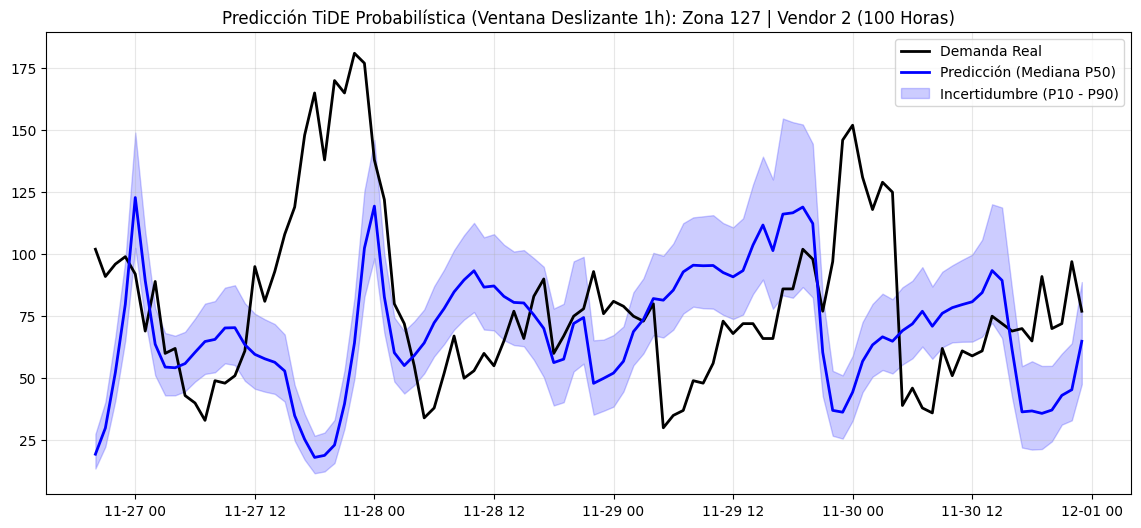

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

modelo_tft = TFTModel.load_from_checkpoint(
    model_name="tft_nyc_v1",          # El nombre que le dimos a la versión
    work_dir="mis_modelos_guardados", # La carpeta "padre" donde se guardó
    best=True  ,                       # ¡Darts buscará el mejor archivo .pth automáticamente!
    weights_only=False  
)
# 1. Buscar la serie exacta
indice_buscado = -1
for i, ts in enumerate(val_target):
    vendor = ts.static_covariates["VendorID"].iloc[0]
    zona = ts.static_covariates["PULocationID"].iloc[0]
    
    if vendor == 2 and zona == 127:
        indice_buscado = i
        break

if indice_buscado == -1:
    print("¡Vaya! La Zona 127 con Vendor 2 no existe o fue descartada.")
else:
    print(f"¡Encontrada! (Serie {indice_buscado}). Preparando la máquina del tiempo...")
    
    # 2. Reconstruimos los ingredientes
    serie_pasado = train_target_scaled[indice_buscado]
    pasado_completo = train_past_scaled[indice_buscado].append(val_past_scaled[indice_buscado])
    futuro_completo = train_future[indice_buscado].append(val_future[indice_buscado])
    
    # Listas para guardar las 100 predicciones
    pred_p10_lista = []
    pred_p50_lista = []
    pred_p90_lista = []
    
    print("Calculando hora a hora (Ventana Deslizante)...")
    
    # 3. EL BUCLE MÁGICO (Predecir solo la siguiente hora, 100 veces)
    for hora in range(100):
        # Pedimos n=1 (¡100% legal para Darts!)
        pred_escalada = modelo_tft.predict(
            n=1,
            series=serie_pasado,
            past_covariates=pasado_completo,
            future_covariates=futuro_completo,
            predict_likelihood_parameters=True, 
            verbose=False # Silenciamos la barra de progreso para que no moleste 100 veces
        )
        
        # Desescalar ese único dato
        pred_real = scaler_target.inverse_transform(pred_escalada)
        df_pred = pred_real.to_dataframe()
        
        # Guardar las 3 líneas
        pred_p10_lista.append(df_pred.iloc[0, 0])
        pred_p50_lista.append(df_pred.iloc[0, 1])
        pred_p90_lista.append(df_pred.iloc[0, 2])
        
        # AVANZAR EN EL TIEMPO: Cogemos la hora real de validación que acaba de pasar
        # y se la pegamos a la serie para que el modelo la use en el siguiente paso
        hora_real = val_target_scaled[indice_buscado][hora : hora+1]
        serie_pasado = serie_pasado.append(hora_real)

    print("¡100 horas completadas con éxito!")
    
    # 4. EXTRAER LOS DATOS REALES (100h) Y CALCULAR EL MAE
    real_100h = val_target[indice_buscado][-100:]
    df_real = real_100h.to_dataframe()
    fechas = df_real.index
    
    # MAE = Media de la diferencia absoluta entre la Realidad y la Mediana P50
    error_mae = np.mean(np.abs(df_real.iloc[:, 0].values - pred_p50_lista))
    print(f"--> MAE Realista (Backtesting 100h): {error_mae:.2f} taxis de error en promedio.")
    
    # 5. ¡A DIBUJAR LA OBRA MAESTRA!
    plt.figure(figsize=(14, 6))
    
    plt.plot(fechas, df_real.iloc[:, 0], label="Demanda Real", color="black", linewidth=2)
    plt.plot(fechas, pred_p50_lista, label="Predicción (Mediana P50)", color="blue", linewidth=2)
    
    # Sombreado de incertidumbre
    plt.fill_between(
        fechas,
        pred_p10_lista,
        pred_p90_lista,
        alpha=0.2, color="blue", label="Incertidumbre (P10 - P90)"
    )
    
    plt.title("Predicción TiDE Probabilística (Ventana Deslizante 1h): Zona 127 | Vendor 2 (100 Horas)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [18]:
import numpy as np

print("Empaquetando los datos de TODAS las zonas...")

# 1. Juntar el pasado y el futuro de todas las series de golpe (List Comprehension)
# Esto crea las listas completas para pasárselas a la GPU
pasados_completos = [t_p.append(v_p) for t_p, v_p in zip(train_past_scaled, val_past_scaled)]
futuros_completos = [t_f.append(v_f) for t_f, v_f in zip(train_future, val_future)]

print("Enviando miles de series a la GPU a la vez... ¡Agárrate!")

# 2. PREDICCIÓN MASIVA EN BATCH
# En lugar de pasar un índice, le pasamos las listas completas. 
# La GPU calculará las >1000 zonas simultáneamente.
preds_escaladas_lista = modelo_tft.predict(
    n=24,
    series=train_target_scaled,       
    past_covariates=pasados_completos, 
    future_covariates=futuros_completos,
    predict_likelihood_parameters=True,
    verbose=True
)

print("Desescalando los resultados a la realidad...")
# 3. Desescalado masivo (El Scaler también puede procesar listas enteras)
preds_reales_lista = scaler_target.inverse_transform(preds_escaladas_lista)

print("Calculando los errores zona por zona...")
# 4. Calcular el error (MAE) iterando sobre los resultados
maes_por_zona = []

for i in range(len(preds_reales_lista)):
    # Extraer la predicción P50 (Mediana)
    df_pred = preds_reales_lista[i].to_dataframe()
    pred_p50 = df_pred.iloc[:, 1].values 
    
    # Extraer la realidad de esa misma zona (las primeras 24h del val_target)
    real_24h = val_target[i][:24].to_dataframe().iloc[:, 0].values
    
    # Calcular el MAE matemático (solo añadimos el error si no hay datos corruptos)
    if len(pred_p50) == len(real_24h):
        error = np.mean(np.abs(real_24h - pred_p50))
        maes_por_zona.append(error)

# 5. RESULTADOS GLOBALES
mae_global = np.mean(maes_por_zona)
mediana_mae = np.median(maes_por_zona)

print("\n==================================================")
print("MAE GLOBAL DEL MODELO (TODAS LAS ZONAS - 24H)")
print("==================================================")
print(f"MAE Promedio: {mae_global:.2f} taxis de error.")
print(f"Mediana MAE:  {mediana_mae:.2f} taxis de error.")
print("==================================================")

Empaquetando los datos de TODAS las zonas...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Enviando miles de series a la GPU a la vez... ¡Agárrate!


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Generating TimeSeries:   0%|          | 0/1031 [00:00<?, ?it/s]

Desescalando los resultados a la realidad...
Calculando los errores zona por zona...

MAE GLOBAL DEL MODELO (TODAS LAS ZONAS - 24H)
MAE Promedio: 6.31 taxis de error.
Mediana MAE:  2.67 taxis de error.
